In [20]:
# ============================================================
# Contrastive GNN Graph Embedding Training
# Small Connected ER Graphs (Weighted / Unweighted)
# QAOA-guided loss: loss = contrastive_loss * (1 - quality)
#   quality = ar * (1 - error_rate)
# ============================================================

import random
import numpy as np
import torch
from src.utils import read_config

In [21]:
# ------------------------
# IMPORTS
# ------------------------

import os
import networkx as nx
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.decomposition import PCA

from torch_geometric.data import Data, DataLoader
from torch_geometric.utils import from_networkx

import torch.nn as nn
import torch.nn.functional as F

from src.embedding.gnn_model import GNNGraphEncoder
from src.adapt_utils import compute_metrics
from src.qaoa_gpt_modified import QAOA_GPT  # modified class with graph_embeddings param

In [22]:
config = read_config(path='config/config.yaml')
SEED = config['gnn']['SEED']

NUM_GRAPHS        = config['gnn']['NUM_GRAPHS']
NODE_CHOICES      = config['gnn']['NODE_CHOICES']
EDGE_P_MIN        = config['gnn']['EDGE_P_MIN']
EDGE_P_MAX        = config['gnn']['EDGE_P_MAX']

WEIGHT_UNIFORM_RANGE = config['gnn']['WEIGHT_UNIFORM_RANGE']
WEIGHT_EXP_LAMBDA    = config['gnn']['WEIGHT_EXP_LAMBDA']
WEIGHTED_RATIO       = config['gnn']['WEIGHTED_RATIO']

NODE_FEATURE_DIM  = config['gnn']['NODE_FEATURE_DIM']
EMBEDDING_DIM     = config['gnn']['EMBEDDING_DIM']
HIDDEN_DIM        = config['gnn']['HIDDEN_DIM']
NUM_LAYERS        = config['gnn']['NUM_LAYERS']

EPOCHS            = config['gnn']['EPOCHS']
LR                = float(config['gnn']['LR'])
WEIGHT_DECAY      = float(config['gnn']['WEIGHT_DECAY'])
BATCH_SIZE        = config['gnn']['BATCH_SIZE']
TEMPERATURE       = config['gnn']['TEMPERATURE']
MODEL_PATH        = config['gnn']['MODEL_PATH']

# QAOA feedback settings  ─ add these keys to config.yaml if desired,
# or hard-code sensible defaults here.
QAOA_EVAL_EVERY   = config['gnn'].get('QAOA_EVAL_EVERY', 5)      # epochs between QAOA calls
QAOA_NUM_GRAPHS   = config['gnn'].get('QAOA_NUM_GRAPHS', 20)     # graphs sampled per QAOA call
QAOA_MODEL_CKPT   = config['gnn']['QAOA_MODEL_CKPT']             # e.g. 'nanoGPT/out-10.../gpt_ckpt_...'
QAOA_DATA_DIR     = config['gnn']['QAOA_DATA_DIR']               # e.g. 'nanoGPT/data/10_nodes_gnn'

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [23]:
# %%
# ------------------------
# EARLY STOPPING CONFIG
# ------------------------

EARLY_STOP_PATIENCE  = config['gnn'].get('EARLY_STOP_PATIENCE',50)
EARLY_STOP_MIN_DELTA = config['gnn'].get('EARLY_STOP_MIN_DELTA', 1e-3)

BEST_QUALITY    = -float('inf')
BEST_EPOCH      = 0
NO_IMPROVE_CNT  = 0

BEST_CKPT = {
    'encoder':   None,
    'projector': None,
    'epoch':     0,
    'quality':   0.0,
    'loss':      float('inf'),   # logged for reference only
}
def composite_score(quality, avg_loss, loss_weight=0.3):
    """
    Single scalar to maximize.
    quality ∈ [0,1] (higher = better)
    avg_loss  (lower = better) → subtract it after light normalization
    loss_weight controls how much loss matters vs quality.
    """
    return quality - loss_weight * avg_loss

In [24]:
# ------------------------
# GRAPH GENERATION
# ------------------------

def generate_connected_er_graph(weighted=True):
    n = random.choice(NODE_CHOICES)
    p = random.uniform(EDGE_P_MIN, EDGE_P_MAX)

    while True:
        G = nx.erdos_renyi_graph(n, p)
        if nx.is_connected(G):
            break

    for u, v in G.edges():
        if weighted:
            if random.random() < 0.5:
                w = np.random.uniform(*WEIGHT_UNIFORM_RANGE)
            else:
                w = np.random.exponential(WEIGHT_EXP_LAMBDA)
            # Clip to valid QAOA range so GNN and QAOA see consistent values
            G[u][v]["weight"] = float(np.clip(w, 0.01, 0.99))
        else:
            G[u][v]["weight"] = 1.0

    for node in G.nodes():
        G.nodes[node]["x"] = np.random.randn(NODE_FEATURE_DIM)

    return G


graphs     = []
graph_types = []

for i in tqdm(range(NUM_GRAPHS), desc="Generating graphs"):
    weighted = random.random() < WEIGHTED_RATIO
    G = generate_connected_er_graph(weighted)
    graphs.append(G)
    graph_types.append(weighted)

print(f"Graphs: {NUM_GRAPHS} | Weighted: {sum(graph_types)}")

Generating graphs:   0%|          | 0/500 [00:00<?, ?it/s]

Generating graphs: 100%|██████████| 500/500 [00:00<00:00, 7779.39it/s]

Graphs: 500 | Weighted: 389


In [25]:
# ------------------------
# PyG DATASET
# ------------------------

data_list = []

for G in graphs:
    data = from_networkx(G)

    data.x = torch.tensor(
        np.vstack([G.nodes[n]["x"] for n in G.nodes()]),
        dtype=torch.float,
    )

    edge_weights = []
    for u, v in G.edges():
        w = G[u][v]["weight"]
        edge_weights.append(w)
        edge_weights.append(w)       # duplicate for (v, u)

    data.edge_weight = torch.tensor(edge_weights, dtype=torch.float)
    data_list.append(data)

loader = DataLoader(data_list, batch_size=BATCH_SIZE, shuffle=True)

/tmp/ipykernel_82728/3571490228.py:24: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  loader = DataLoader(data_list, batch_size=BATCH_SIZE, shuffle=True)


In [26]:
def graphs_to_qaoa_dict(nx_graphs):
    """
    Wrap nx graphs in the dict format expected by prepare_model_input.
    Weights are clipped to [0.01, 0.99] and rounded to 2dp to match
    the QAOA tokenizer vocabulary (stoi).
    """
    qaoa_graphs = {}
    for i, G in enumerate(nx_graphs):
        G_rounded = G.copy()
        for u, v in G_rounded.edges():
            w = float(G_rounded[u][v]["weight"])
            w = round(float(np.clip(w, 0.01, 0.99)), 2)
            G_rounded[u][v]["weight"] = w
        qaoa_graphs[f"er_graph_{i}"] = G_rounded
    return qaoa_graphs

def compute_qaoa_quality(encoder, nx_graphs, qaoa_model, device):
    encoder.eval()
    sample_data_list = []

    for G in nx_graphs:
        data = from_networkx(G)
        data.x = torch.tensor(
            np.vstack([G.nodes[n]["x"] for n in G.nodes()]),
            dtype=torch.float,
        )
        edge_weights = []
        for u, v in G.edges():
            w = G[u][v]["weight"]
            edge_weights.append(w)
            edge_weights.append(w)
        data.edge_weight = torch.tensor(edge_weights, dtype=torch.float)
        sample_data_list.append(data)

    sample_loader = DataLoader(sample_data_list, batch_size=len(sample_data_list), shuffle=False)

    with torch.no_grad():
        batch = next(iter(sample_loader)).to(device)
        gnn_embeddings = encoder(batch.x, batch.edge_index, batch.batch)

    # Pass nx graph dict directly — prepare_model_input calls nx_to_elist internally
    graphs_dict = graphs_to_qaoa_dict(nx_graphs)

    circ_df = qaoa_model.generate_circ_from_nx(
        graphs_dict,
        graph_embeddings=gnn_embeddings,
        n_samples_per_batch=len(nx_graphs),
        num_samples=3,
        max_new_tokens=150,
        temperature=0.1,
        top_k=200,
    )
    eval_df = qaoa_model.eval_circ_df_jl(circ_df)

    ar, err, layers = compute_metrics(eval_df)
    quality = ar * (1.0 - err)

    print(f"  [QAOA] AR={ar:.4f}  ERR={err:.4f}  Layers={layers:.1f}  Quality={quality:.4f}")

    encoder.train()
    return quality

In [27]:
# ------------------------
# AUGMENTATION
# ------------------------

def augment_graph(data, edge_drop_p=0.1, weight_noise=0.1, x_noise=0.1):
    data = data.clone()

    if edge_drop_p > 0:
        num_edges = data.edge_index.size(1)
        mask = torch.rand(num_edges, device=data.edge_index.device) > edge_drop_p
        data.edge_index = data.edge_index[:, mask]
        if hasattr(data, "edge_weight"):
            data.edge_weight = data.edge_weight[mask]

    if hasattr(data, "edge_weight"):
        data.edge_weight = data.edge_weight * (
            1.0 + weight_noise * torch.randn_like(data.edge_weight)
        )

    data.x = data.x + x_noise * torch.randn_like(data.x)
    return data

In [28]:
# ------------------------
# CONTRASTIVE LOSS
# ------------------------

def contrastive_loss(z1, z2, temperature=TEMPERATURE):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    logits = torch.mm(z1, z2.t()) / temperature
    labels = torch.arange(z1.size(0), device=z1.device)
    return F.cross_entropy(logits, labels)

In [29]:
# ------------------------
# MODEL + PROJECTION HEAD
# ------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

encoder = GNNGraphEncoder(
    in_dim=NODE_FEATURE_DIM,
    hidden_dim=HIDDEN_DIM,
    embedding_dim=EMBEDDING_DIM,
    num_layers=NUM_LAYERS,
).to(device)

projector = nn.Sequential(
    nn.Linear(EMBEDDING_DIM, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
).to(device)

params    = list(encoder.parameters()) + list(projector.parameters())
optimizer = torch.optim.Adam(params, lr=LR, weight_decay=WEIGHT_DECAY)

# ── QAOA model (frozen; used only for feedback signal) ──────────────────────
qaoa_model = QAOA_GPT(
    model_ckpt=QAOA_MODEL_CKPT,
    data_dir=QAOA_DATA_DIR,
)

Device: cuda

Model type: gpt
Pool type: qaoa_double_pool
Embedding method: gnn
Number of nodes: 10
Initiating nanoGPT model with padding support
number of parameters: 11.68M


In [30]:
# %%
# ------------------------
# TRAINING LOOP
# ------------------------

loss_history    = []
quality_history = []

current_quality = 0.0

encoder.train()
projector.train()

for epoch in range(1, EPOCHS + 1):

    # ── QAOA quality feedback ────────────────────────────────────────────────
    if epoch % QAOA_EVAL_EVERY == 0:
        sample_graphs   = random.sample(graphs, min(QAOA_NUM_GRAPHS, len(graphs)))
        current_quality = compute_qaoa_quality(encoder, sample_graphs, qaoa_model, device)
        quality_history.append((epoch, current_quality))
        encoder.train()
        projector.train()

        # ── Early stopping: quality only ─────────────────────────────────────
        if current_quality > BEST_QUALITY + EARLY_STOP_MIN_DELTA:
            BEST_QUALITY   = current_quality
            BEST_EPOCH     = epoch
            NO_IMPROVE_CNT = 0
            BEST_CKPT['encoder']   = {k: v.cpu().clone() for k, v in encoder.state_dict().items()}
            BEST_CKPT['projector'] = {k: v.cpu().clone() for k, v in projector.state_dict().items()}
            BEST_CKPT['epoch']     = epoch
            BEST_CKPT['quality']   = current_quality
            BEST_CKPT['loss']      = avg_loss   # just for logging
            print(f"  ✓ New best  quality={BEST_QUALITY:.4f}  loss={avg_loss:.4f}")
        else:
            NO_IMPROVE_CNT += 1
            print(f"  No improvement ({NO_IMPROVE_CNT}/{EARLY_STOP_PATIENCE // QAOA_EVAL_EVERY})")

        if NO_IMPROVE_CNT >= EARLY_STOP_PATIENCE // QAOA_EVAL_EVERY:
            print(f"\nEarly stopping at epoch {epoch}. "
                  f"Best epoch {BEST_EPOCH} — quality={BEST_QUALITY:.4f}")
            break

    # ── Contrastive training pass ────────────────────────────────────────────
    total_loss = 0.0

    for batch in loader:
        batch  = batch.to(device)
        batch1 = augment_graph(batch)
        batch2 = augment_graph(batch)

        z1 = encoder(batch1.x, batch1.edge_index, batch1.batch)
        z2 = encoder(batch2.x, batch2.edge_index, batch2.batch)

        p1 = projector(z1)
        p2 = projector(z2)

        c_loss = contrastive_loss(p1, p2)
        loss   = c_loss * (1.0 - current_quality)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)

    if epoch % 2 == 0:
        print(f"Epoch {epoch:03d} | Loss: {avg_loss:.4f}  quality={current_quality:.4f}")

# ── Restore best weights ──────────────────────────────────────────────────────
if BEST_CKPT['encoder'] is not None:
    print(f"\nRestoring best model from epoch {BEST_CKPT['epoch']} "
          f"(quality={BEST_CKPT['quality']:.4f})")
    encoder.load_state_dict({k: v.to(device) for k, v in BEST_CKPT['encoder'].items()})
    projector.load_state_dict({k: v.to(device) for k, v in BEST_CKPT['projector'].items()})
else:
    print("No QAOA eval completed — keeping final weights.")

Epoch 002 | Loss: 1.0785  quality=0.0000


/tmp/ipykernel_82728/397271752.py:35: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  sample_loader = DataLoader(sample_data_list, batch_size=len(sample_data_list), shuffle=False)


Epoch 004 | Loss: 0.8413  quality=0.0000


Preparing graphs...: 100%|██████████| 20/20 [00:00<00:00, 328.84it/s]


Performing gnn embedding
GNN model initialized on device: cuda


...

Performing gnn embedding
GNN model initialized on device: cuda


GNN: 100%|██████████| 4/4 [00:00<00:00, 374.68it/s]


GNN shape: (4, 500)


Inference. Current batch: n_edges: 29, n_graphs: 1: 100%|██████████| 4/4 [00:01<00:00,  2.26it/s]



===== DEBUG INFO =====
CWD: /home/mrzaizai2k/code_bao/ADAPT_GPT
Command:
/opt/julia-1.12.1/bin/julia -t 4 --project=/home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/adapt_gpt_eval_energy.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-09__16_19_56_df.json /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-09__16_19_56_df_jl.json 10 qaoa_double_pool


Julia return code: 0
  [QAOA] AR=0.9112  ERR=0.2500  Layers=5.8  Quality=0.6834
  No improvement (10/10)

Early stopping at epoch 110. Best epoch 60 — quality=0.9130

Restoring best model from epoch 60 (quality=0.9130)


NameError: name 'score_history' is not defined

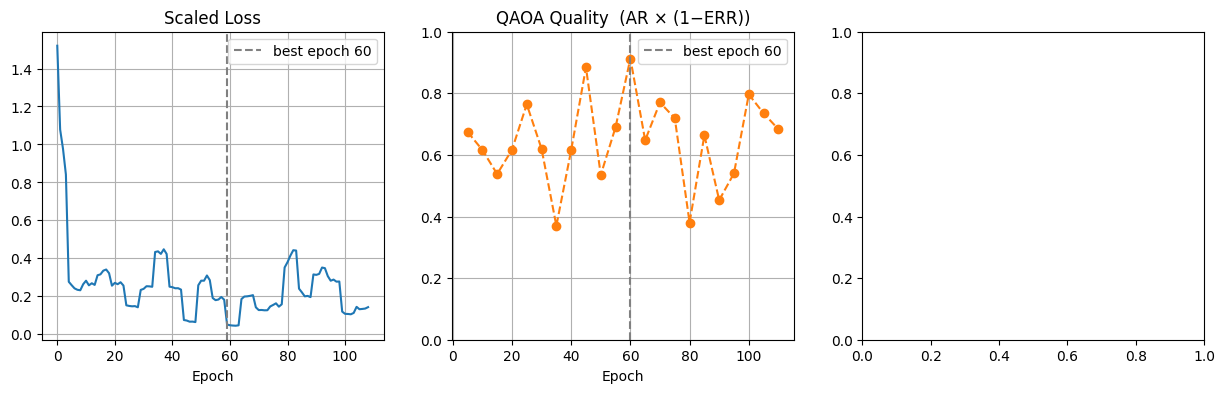

In [31]:
# %%
# ------------------------
# LOSS CURVE
# ------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(loss_history, color="tab:blue")
axes[0].axvline(BEST_CKPT['epoch'] - 1, color='gray', linestyle='--', label=f"best epoch {BEST_CKPT['epoch']}")
axes[0].set_title("Scaled Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

if quality_history:
    epochs_q, qualities = zip(*quality_history)
    axes[1].plot(epochs_q, qualities, "o--", color="tab:orange")
    axes[1].axvline(BEST_CKPT['epoch'], color='gray', linestyle='--', label=f"best epoch {BEST_CKPT['epoch']}")
    axes[1].set_title("QAOA Quality  (AR × (1−ERR))")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(True)

axes[2].plot(score_history, color="tab:green")
axes[2].axvline(BEST_CKPT['epoch'] - 1, color='gray', linestyle='--', label=f"best epoch {BEST_CKPT['epoch']}")
axes[2].set_title("Composite Score  (quality − 0.3·loss)")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [32]:
# ------------------------
# SAVE ENCODER ONLY
# ------------------------

os.makedirs("models", exist_ok=True)
torch.save(encoder.state_dict(), MODEL_PATH)
print(f"Saved encoder to {MODEL_PATH}")

Saved encoder to models/gnn_graph_encoder_contrastive.pt


In [33]:
# ------------------------
# EXTRACT FINAL GRAPH EMBEDDINGS
# ------------------------

encoder.eval()
embeddings = []

with torch.no_grad():
    for batch in loader:
        batch = batch.to(device)
        emb   = encoder(batch.x, batch.edge_index, batch.batch)
        embeddings.append(emb.cpu().numpy())

embeddings = np.vstack(embeddings)
print("Embedding shape:", embeddings.shape)

Embedding shape: (500, 500)


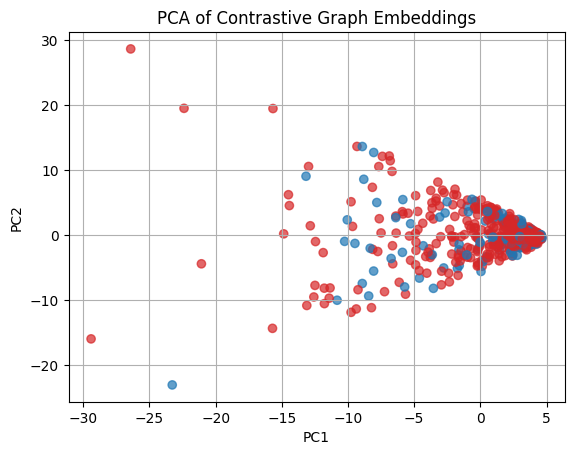

In [34]:
# ------------------------
# PCA VISUALIZATION
# ------------------------

emb_2d = PCA(n_components=2).fit_transform(embeddings)
colors = ["tab:red" if w else "tab:blue" for w in graph_types]

plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, alpha=0.7)
plt.title("PCA of Contrastive Graph Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()